In [171]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import chess
import ipywidgets as widgets
import matplotlib.pyplot as plt

from beschess.data.embedding import BalancedBatchSampler, PuzzleDataset, generate_split_indices
from beschess.components.net.vit import get_interpretable_vit, extract_attention_weights, compute_attention_rollout, compute_head_importance, compute_faithfulness_map
from beschess.viz import plot_attention_overlay, plot_attention_rollout_overlay, plot_chessboard_overlay, plot_attention_move_overlay
from beschess.utils import tensor_to_board, board_to_packed, packed_to_tensor

%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [172]:
checkpoint_path = "../checkpoints/FineTune_Stage2_A100_20251206_2238/best_checkpoint.pth"
model = get_interpretable_vit(
    in_channels=17,
    embed_dim=256,
    num_heads=8,
    depth=6,
    out_dim=128,
    path_to_weights=checkpoint_path,
)

In [173]:
# board_fen = "q6k/8/8/8/P7/8/8/R6K w Q - 0 1"
# board_fen = "q6k/8/8/8/8/8/8/R6K w Q - 0 1"

# board_fen = "q6k/5pp1/8/8/P7/8/5PPP/R6K w Q - 0 1"
board_fen = "q6k/5pp1/8/8/8/8/5PPP/R6K w Q - 0 1"

# board_fen = "8/R7/4p3/5p1k/5P2/5KP1/8/7r w - - 0 1"
# board_fen = "r1bq2kr/ppp1n1b1/3p1R1p/7Q/3P4/8/PPP3PP/RNB3K1 w - - 0 1"
# board_fen = "r1bq3r/ppp1nQbk/3p1R1p/8/3P4/8/PPP3PP/RNB3K1 w - - 0 1"
# board_fen = "8/R2q1k1p/5bp1/2Bpn3/2p1p1P1/7P/4BP2/4R1K1 w - - 4 3"
board = chess.Board(board_fen)
input_tensor = torch.tensor(packed_to_tensor(board_to_packed(board))).unsqueeze(0)
model.eval()
with torch.no_grad():
    embedding, puzzle_prob, attn_weights = extract_attention_weights(model, input_tensor)

board = tensor_to_board(input_tensor.squeeze(0).numpy())
print(puzzle_prob.item())

0.7078021764755249


In [174]:
w = widgets.interact(
    plot_attention_overlay,
    board=widgets.fixed(board),
    attention_maps=widgets.fixed(attn_weights[0].numpy()),
    depth=widgets.IntSlider(min=0, max=6-1, step=1, value=3),
    query_idx=widgets.IntSlider(min=0, max=65-1, step=1, value=0),
    head_idx=widgets.IntSlider(min=0, max=8-1, step=1, value=5),
)

interactive(children=(IntSlider(value=0, description='query_idx', max=64), IntSlider(value=5, description='hea…

In [175]:
# save svg
svg = plot_attention_overlay(board, attn_weights[0].numpy(), depth=3, query_idx=1, head_idx=5)
with open("attention_overlay.svg", "w") as f:
    f.write(svg)

In [176]:
importance = np.asarray(compute_head_importance(model, input_tensor))
threshold = np.percentile(importance[:, 2], 95)
importance = importance[importance[:, 2] >= threshold]
importance = [(int(head_idx), int(depth), float(imp)) for head_idx, depth, imp in importance]
importance

[(6, 3, 2.1184503040672098e-08),
 (5, 3, 1.8899905640523684e-08),
 (1, 3, 1.7709893995743187e-08)]

Depth: 3, Head: 6


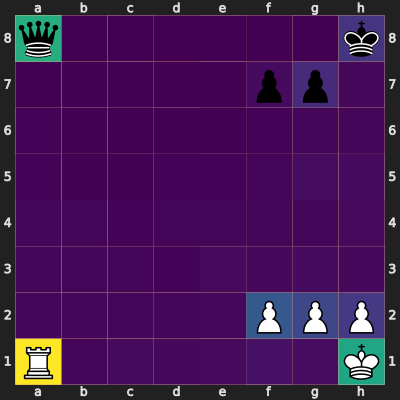

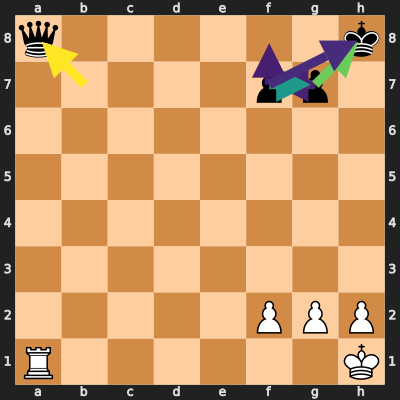

Depth: 3, Head: 5


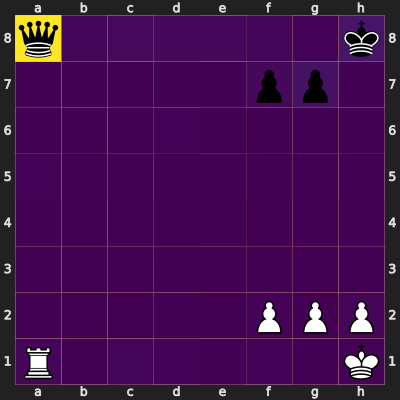

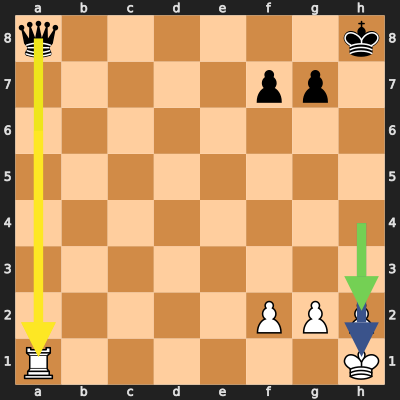

Depth: 3, Head: 1


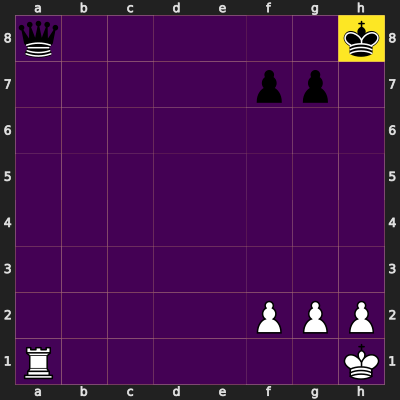

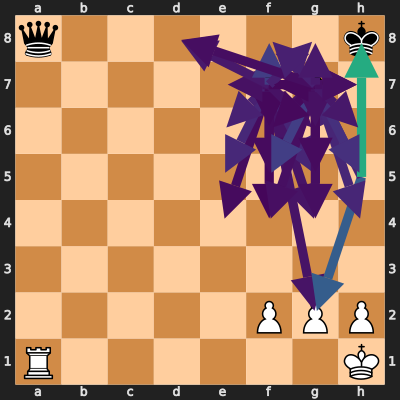

In [177]:
for head_idx, depth, imp in importance:
    print(f"Depth: {depth}, Head: {head_idx}")
    display(plot_attention_overlay(
        board=board,
        attention_maps=attn_weights.numpy().sum(axis=0),
        depth=depth,
        query_idx=0,
        head_idx=head_idx,
    ))
    display(plot_attention_move_overlay(
        board=board,
        attention_maps=attn_weights[0].numpy(),
        depth=depth,
        head_idx=head_idx,
    ))

In [178]:
rollout = compute_attention_rollout(attn_weights)
w = widgets.interact(
    plot_attention_rollout_overlay,
    board=widgets.fixed(board),
    rollout_map=widgets.fixed(rollout[0].numpy()),
    query_idx=widgets.IntSlider(min=0, max=65-1, step=1, value=0),
)

interactive(children=(IntSlider(value=0, description='query_idx', max=64), IntSlider(value=400, description='s…

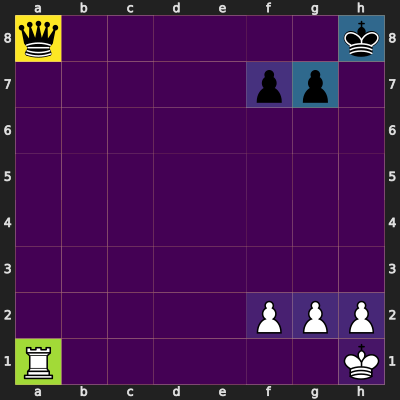

In [179]:
faithfulness = compute_faithfulness_map(model, input_tensor)
plot_chessboard_overlay(
    board=board,
    overlay_vals=faithfulness,
)